# Feature-Based Classifier (Logistic Regression)

In [1]:
from maverick import Maverick
import spacy
from spacy.tokens import Doc
import sys
from modules.utils.dict_utils import check_dictionary
from nltk.corpus import wordnet as wn
from modules.explicit_cues import fem_lex, masc_lex, neutral_lex
import gender_guesser.detector as gender
from modules.explicit_cues import is_negated, is_person, ner_person, is_plural, conj_chain, longest_cluster_for_token, syntactic_indexes, gender_person_token
from modules.evaluation import prepare_examples, build_feature_dict, load_dataset, evaluate_test_set, find_seed_token_index
import numpy as np
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sapienzanlp/maverick-mes-preco loading


Loading weights: 100%|█████████████████████| 390/390 [00:00<00:00, 17084.03it/s]
[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/archite

sapienzanlp/maverick-mes-preco loading


Loading weights: 100%|█████████████████████| 390/390 [00:00<00:00, 17624.46it/s]
[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/archite

In [2]:
nlp = spacy.load("en_core_web_md")

In [3]:
coref_model = Maverick(
  hf_name_or_path = "sapienzanlp/maverick-mes-preco",
  device = "cpu"
)

coref_model.model = coref_model.model.float() 

sapienzanlp/maverick-mes-preco loading


Loading weights: 100%|█████████████████████| 390/390 [00:00<00:00, 19703.43it/s]
[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/archite

## Data

In [4]:
glitter_path = '../data/glitter.parquet'
glitter_dev = '../data/glitter-splits/glitter-dev.tsv'
glitter_test = '../data/glitter-splits/glitter-test.tsv'
glitter_train = '../data/glitter-splits/glitter-train.tsv'

fairtranslate_dev = '../data/fairtranslate-splits/fairtranslate-dev.tsv'
fairtranslate_test = '../data/fairtranslate-splits/fairtranslate-test.tsv'
fairtranslate_train = '../data/fairtranslate-splits/fairtranslate-train.tsv'

gente_path = '../data/GeNTE/GeNTE.tsv'
gente_dev = '../data/gente-splits/gente-dev.tsv'
gente_test = '../data/gente-splits/gente-test.tsv'
gente_train = '../data/gente-splits/gente-train.tsv'
gente_full = '../data/gente-splits/gente-full.tsv'

female_lexical = '../data/lexical-splits/lexical-female.tsv'
male_lexical = '../data/lexical-splits/lexical-male.tsv'
lexical_dev = '../data/lexical-splits/lexical-dev.tsv'
lexical_test = '../data/lexical-splits/lexical-test.tsv'
lexical_train = '../data/lexical-splits/lexical-train.tsv'

### Lexical Gender

In [5]:
def lexical_gender(lemma):
    if lemma in fem_lex:
        lex_gender = 'fem'
    elif lemma in masc_lex:
        lex_gender = 'masc'
    elif lemma in neutral_lex:
        lex_gender = 'neutral'
    else:
        lex_gender = check_dictionary(
            word=token.lemma_, dict_abbrev='wordnet',
            heuristics=True, seed_pairs=5,
            no_words=35, no_defs=10)
        
    return lex_gender

In [6]:
print('Example')
print('Word: princess')
print('Lexical Gender:',lexical_gender('princess'))

Example
Word: princess
Lexical Gender: fem


## Coref Features

In [7]:
def coref_clusters(spacy_doc):
    tokens = []
    for token in spacy_doc:
        tokens.append(token.text)
    entity_dict = coref_model.predict(tokens, singletons=True)
    return entity_dict

text = 'The teachers were a group that included women.'

spacy_doc = nlp(text)

entity_clusters = coref_clusters(spacy_doc)


print(entity_clusters)

{'tokens': ['The', 'teachers', 'were', 'a', 'group', 'that', 'included', 'women', '.'], 'clusters_token_offsets': [((0, 1), (3, 7)), ((7, 7),)], 'clusters_char_offsets': None, 'clusters_token_text': [['The teachers', 'a group that included women'], ['women']], 'clusters_char_text': None}


In [8]:
def build_token_to_cluster(entity_dict, spacy_doc):
    """
    builds a dict mapping token index -> (cluster_words, cluster_spans)
    for every token that appears in any coref cluster.
    """
    token_to_cluster = {}
    for cluster_words, cluster_spans in zip(
        entity_dict['clusters_token_text'],
        entity_dict['clusters_token_offsets']
    ):
        for span in cluster_spans:
            for i in range(span[0], span[1] + 1):
                token_to_cluster[i] = (cluster_words, cluster_spans)
    return token_to_cluster

build_token_to_cluster(entity_clusters, spacy_doc)

{0: (['The teachers', 'a group that included women'], ((0, 1), (3, 7))),
 1: (['The teachers', 'a group that included women'], ((0, 1), (3, 7))),
 3: (['The teachers', 'a group that included women'], ((0, 1), (3, 7))),
 4: (['The teachers', 'a group that included women'], ((0, 1), (3, 7))),
 5: (['The teachers', 'a group that included women'], ((0, 1), (3, 7))),
 6: (['The teachers', 'a group that included women'], ((0, 1), (3, 7))),
 7: (['women'], ((7, 7),))}

### Pronoun Gender

In [9]:
def pronoun_gender(token_index, entity_clusters, spacy_doc):
    """
    checks whether the token at token_index is the head of a mention span
    in its coreference cluster, and whether the cluster contains male/female pronouns.

    returns 'masc', 'fem', or 'neutral'.
    """

    token_to_cluster = build_token_to_cluster(entity_clusters, spacy_doc)
    
    if token_index not in token_to_cluster:
        return 'neutral'

    cluster_words, cluster_spans = token_to_cluster[token_index]

    is_head = False
    for span in cluster_spans:
        head = spacy_doc[span[0]:(span[1] + 1)].root
        if head.i == token_index:
            is_head = True
            break

    if not is_head:
        return 'neutral'

    masculine_pronouns = 0
    feminine_pronouns = 0
    for word in cluster_words:
        if word.lower() in ['he', 'him', 'his', 'himself']:
            masculine_pronouns += 1
        elif word.lower() in ['she', 'her', 'herself']:
            feminine_pronouns += 1

    if masculine_pronouns > feminine_pronouns:
        return 'masc'
    elif feminine_pronouns > masculine_pronouns:
        return 'fem'
    else:
        return 'neutral'

In [10]:
print(pronoun_gender(3, entity_clusters, spacy_doc))

neutral


### Lexical Coref Gender

In [11]:
def longest_cluster_for_token(token_index, entity_dict):
    """
    finds the cluster (by index into entity_dict) containing token_index
    with the most mentions. ties are broken by total token length
    across all mentions.
    """
    cluster_spans_list = entity_dict['clusters_token_offsets']

    best_index = None
    best_mentions = -1
    best_length = -1

    for c in range(len(cluster_spans_list)):
        spans = cluster_spans_list[c]
        found = False
        for span in spans:
            if token_index >= span[0] and token_index <= span[1]:
                found = True
                break

        if not found:
            continue

        num_mentions = len(spans)
        total_length = 0
        for span in spans:
            total_length = total_length + (span[1] - span[0] + 1)

        if num_mentions > best_mentions:
            best_index = c
            best_mentions = num_mentions
            best_length = total_length
        elif num_mentions == best_mentions and total_length > best_length:
            best_index = c
            best_mentions = num_mentions
            best_length = total_length

    return best_index

### Simple Feature

The classifier does not use this feature

In [12]:
def collect_relevant_tokens(head, spacy_doc):
    """
    collects the head, its conjuncts, and additionally, if the head has a
    prepositional phrase with 'of' (e.g. 'a group of men and women'), also
    the pobj of that preposition and its conjuncts.
    """
    tokens = [head] + conj_chain(head)

    for child in head.children:
        if child.dep_ == 'prep' and child.lemma_.lower() == 'of':
            for pobj in child.children:
                if pobj.dep_ == 'pobj':
                    tokens.append(pobj)
                    tokens.extend(conj_chain(pobj))

    return tokens

In [ ]:
def lexical_ref_gender(token_index, entity_dict, spacy_doc,
                        fem_mod_indexes, masc_mod_indexes, person_indexes):
    exhaustive_verbs = {'consist', 'comprise'}
    inclusive_verbs = {'include', 'contain', 'feature', 'encompass', 'involve'}
    partitive_quantifiers = {
        'some', 'several', 'many', 'few', 'half', 'part', 'most',
        'majority', 'minority', 'any', 'certain', 'various',
        'handful', 'couple', 'bunch', 'number', 'portion',
        'fraction', 'share', 'lot', 'none'
    }
    cluster_index = longest_cluster_for_token(token_index, entity_dict)
    if cluster_index is None:
        return 'no_coref'
    cluster_spans = entity_dict['clusters_token_offsets'][cluster_index]
    has_plural = False
    for span in cluster_spans:
        head = spacy_doc[span[0]:(span[1] + 1)].root
        if is_plural(head):
            has_plural = True
    if has_plural:
        number_part = 'plur'
    else:
        number_part = 'sing'
    found_genders = []
    inclusion = 'nothing'
    for span in cluster_spans:
        head = spacy_doc[span[0]:(span[1] + 1)].root
        tokens_to_check = collect_relevant_tokens(head, spacy_doc)
        for t in tokens_to_check:
            is_person_token = (t.pos_ in ('NOUN', 'PROPN') and is_person(t.lemma_)) or t.i in person_indexes
            if not is_person_token:
                continue
            in_masc = masc_mod_indexes and t.i in masc_mod_indexes
            in_fem = fem_mod_indexes and t.i in fem_mod_indexes
            if in_masc and 'm' not in found_genders:
                found_genders.append('m')
            if in_fem and 'f' not in found_genders:
                found_genders.append('f')
            if t.lemma_ in masc_lex and 'm' not in found_genders:
                found_genders.append('m')
            if t.lemma_ in fem_lex and 'f' not in found_genders:
                found_genders.append('f')
            if inclusion != 'all':
                start = max(0, t.i - 5)
                end = min(len(spacy_doc), t.i + 3)
                for w in spacy_doc[start:end]:
                    if w.i == t.i:
                        continue
                    lemma = w.lemma_.lower()
                    if lemma in exhaustive_verbs:
                        inclusion = 'all'
                        break
                    if lemma in inclusive_verbs or lemma in partitive_quantifiers:
                        inclusion = 'some'
    if len(found_genders) == 0:
        gender_part = 'neut'
    else:
        gender_part = ''
        for g in found_genders:
            gender_part = gender_part + g
    feature = number_part + '_' + gender_part + '_' + inclusion
    return feature

In [13]:
print(spacy_doc)


text = 'The nuns and the monks were friends'
spacy_doc = nlp(text)
tokens = [token.text for token in spacy_doc]

fem_mod_indexes, masc_mod_indexes, attr_indexes, person_indexes = syntactic_indexes(spacy_doc)

lexical_ref_gender(
        6, entity_clusters, spacy_doc,
        fem_mod_indexes, masc_mod_indexes, person_indexes
    )

The teachers were a group that included women.


'plur_fm_nothing'

### Combined Feature

In [14]:
def plural_conj_cluster(token, entity_dict, spacy_doc, fem_mod_indexes, masc_mod_indexes, person_indexes):
    
    if is_plural(token):
        number_part = 'plural'
    else:
        number_part = 'sing'

    is_conj = False
    if token.dep_ == 'conj':
        is_conj = True
    for child in token.children:
        if child.dep_ == 'conj':
            is_conj = True

    if is_conj:
        conj_part = 'conj'
    else:
        conj_part = 'noconj'

    cluster_index = longest_cluster_for_token(token.i, entity_dict)

    if cluster_index is None:
        cluster_plural_part = 'noplural'
        gender_set_part = 'n'
        cluster_words = []
    else:
        cluster_spans = entity_dict['clusters_token_offsets'][cluster_index]
        cluster_words = entity_dict['clusters_token_text'][cluster_index]

        cluster_has_plural = False
        for span in cluster_spans:
            head = spacy_doc[span[0]:(span[1] + 1)].root
            if is_plural(head):
                cluster_has_plural = True

        if cluster_has_plural:
            cluster_plural_part = 'plural'
        else:
            cluster_plural_part = 'noplural'

        gender_letters = []
        for span in cluster_spans:
            head = spacy_doc[span[0]:(span[1] + 1)].root
            tokens_to_check = collect_relevant_tokens(head, spacy_doc)

            for ref_token in tokens_to_check:
                if not (is_person(ref_token.lemma_) or ref_token.i in person_indexes):
                    continue

                ref_label = gender_person_token(
                    ref_token, cluster_words,
                    fem_mod_indexes, masc_mod_indexes,
                    person_indexes, spacy_doc
                )

                if ref_label == 'unambiguous_male':
                    letter = 'm'
                elif ref_label == 'unambiguous_female':
                    letter = 'f'
                elif ref_label == 'unambiguous_all':
                    letter = 'a'
                elif ref_label == 'ambiguous':
                    letter = 'n'
                else:
                    letter = None

                if letter is not None and letter not in gender_letters:
                    gender_letters.append(letter)

        gender_set_part = ''
        if 'm' in gender_letters:
            gender_set_part = gender_set_part + 'm'
        if 'f' in gender_letters:
            gender_set_part = gender_set_part + 'f'
        if 'n' in gender_letters:
            gender_set_part = gender_set_part + 'n'
        if 'a' in gender_letters:
            gender_set_part = gender_set_part + 'a'

        if gender_set_part == '':
            gender_set_part = 'n'

    own_label = gender_person_token(
        token, cluster_words,
        fem_mod_indexes, masc_mod_indexes,
        person_indexes, spacy_doc
    )

    if own_label == 'unambiguous_male':
        own_part = 'masc'
    elif own_label == 'unambiguous_female':
        own_part = 'fem'
    elif own_label == 'unambiguous_all':
        own_part = 'all'
    else:
        own_part = 'neut'

    feature = number_part +  '_' + cluster_plural_part + '_' + gender_set_part + '_' + own_part
    return feature

In [15]:
plural_conj_cluster(spacy_doc[6], entity_clusters, spacy_doc, fem_mod_indexes, masc_mod_indexes, person_indexes)

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('entity.n.01') at depth 7
  for synset in acyclic_breadth_first(self, rel, depth):


'plural_plural_mf_neut'

In [16]:
text = 'She was a journalist and a doctor'
spacy_doc = nlp(text)
tokens = [token.text for token in spacy_doc]
entity_clusters = coref_clusters(spacy_doc)

fem_mod_indexes, masc_mod_indexes, attr_indexes, person_indexes = syntactic_indexes(spacy_doc)

lexical_ref_gender(
        3, entity_clusters, spacy_doc,
        fem_mod_indexes, masc_mod_indexes, person_indexes
    )



'sing_neut_nothing'

In [17]:
plural_conj_cluster(spacy_doc[3], entity_clusters, spacy_doc, fem_mod_indexes, masc_mod_indexes, person_indexes)

'sing_noplural_f_fem'

### Dependencies

In [18]:
def fallback_cues(spacy_text):
    genders =  []
    gender = None
    include = False
    both = False
    female = ['female', 'woman', 'women']
    male = ['male', 'man', 'men']
    mixed = ['mixed-gender', 'genders', 'mixed']
    fem = 0
    masc = 0
    mix = 0
    
    for token in spacy_text:
        lexical_gender = 'neutral'
        lemma = token.lemma_
        if lemma == 'include' or lemma == 'consist' or lemma == 'contain':
            include = True
        if lemma in fem_lex:
            lexical_gender = 'fem'
            #print(lemma, 'fem lex')
        elif lemma in masc_lex:
            lexical_gender = 'masc'
            #print(lemma, 'masc lex')
        #elif token.pos_ == 'NOUN' and is_person(lemma) == True:
            #print('looking at lexical gender', token)
            #lexical_gender = check_dictionary(word=lemma, 
             #            dict_abbrev='wordnet', 
         #                heuristics=True, 
          #               seed_pairs=5, no_words=35, no_defs=10)
        if token.text in female or lexical_gender == 'fem':
            genders.append(('female', token))
            #print('female', token)
        if token.text in male or lexical_gender == 'masc':
            genders.append(('male', token))
        if token.text in mixed:
            genders.append(('mixed', token))



    if len(genders) == 1:
        gender = genders[0][0]
    elif genders == []:
        gender = 'ambiguous'
    else:
        for g in genders:
            if g[0] == 'female':
                fem += 1
            elif g[0] == 'male':
                masc += 1
            elif g[0] == 'mixed':
                mix += 1

    if masc > 0 and fem == 0 and mix == 0:
        gender = 'male'
    elif masc == 0 and fem > 0 and mix == 0:
        gender = 'female'
    elif masc == 0 and fem == 0 and mix > 0:
        gender = 'mixed'
    elif masc > 0 and fem > 0:
        gender = 'mixed'
        both = True
        

    return gender, genders, include, both

In [ ]:
def dependency_path(token1, token2):
    """
    returns tuple (distance, directed dep path) between two tokens in the dependency tree

    returns (None, None) if no common ancestor (e.g. tokens are in different sentences).
    """

    chain1 = []
    chain1.append(token1)
    current = token1
    while current.head.i != current.i:
        current = current.head
        chain1.append(current)


    chain2 = []
    chain2.append(token2)
    current = token2
    while current.head.i != current.i:
        current = current.head
        chain2.append(current)

    #lowest common ancestor
    lca = None
    for a1 in chain1:
        for a2 in chain2:
            if a1.i == a2.i:
                lca = a1
                break
        if lca is not None:
            break

    if lca is None:
        return None, None

    #token 1 to lca
    up_parts = []
    current = token1
    while current.i != lca.i:
        up_parts.append('up_' + current.dep_)
        current = current.head

    #token 2 to lca
    down_parts = []
    current = token2
    while current.i != lca.i:
        down_parts.append('down_' + current.dep_)
        current = current.head
    down_parts.reverse()

    distance = len(up_parts) + len(down_parts)

    path_parts = up_parts + down_parts
    path_string = '_'.join(path_parts)
    if path_string == '':
        path_string = 'self'

    return distance, path_string

In [19]:
def closest_gendered_dep_path(token, spacy_doc, fem_mod_indexes, masc_mod_indexes, person_indexes, gender='any'):
    """
    returns shortest dep path between a gender cue and the target noun.
    """
    #check if token itself is gendered
    token_is_masc = token.lemma_ in masc_lex
    token_is_fem = token.lemma_ in fem_lex
    if masc_mod_indexes and token.i in masc_mod_indexes:
        token_is_masc = True
    if fem_mod_indexes and token.i in fem_mod_indexes:
        token_is_fem = True

    if gender == 'any' and (token_is_masc or token_is_fem):
        return 'is_cue'
    if gender == 'masc' and token_is_masc:
        return 'is_masc'
    if gender == 'fem' and token_is_fem:
        return 'is_fem'

    #find closest gender cue
    best_distance = None
    best_path = None

    for other in spacy_doc:
        if other.i == token.i:
            continue

        is_person_token = (other.pos_ in ('NOUN', 'PROPN') and is_person(other.lemma_)) or other.i in person_indexes
        if not is_person_token:
            continue

        other_is_masc = other.lemma_ in masc_lex
        other_is_fem = other.lemma_ in fem_lex
        if masc_mod_indexes and other.i in masc_mod_indexes:
            other_is_masc = True
        if fem_mod_indexes and other.i in fem_mod_indexes:
            other_is_fem = True

        if not other_is_masc and not other_is_fem:
            continue
        if gender == 'masc' and not other_is_masc:
            continue
        if gender == 'fem' and not other_is_fem:
            continue

        distance, path = dependency_path(token, other)
        if distance is None:
            continue

        if best_distance is None or distance < best_distance:
            best_distance = distance
            best_path = path

    if best_path is None:
        return 'none'

    return best_path

    

In [20]:
text = "The teachers, who were a group of nuns and monks, loved dancing"
spacy_doc = nlp(text)
fem_mod_indexes, masc_mod_indexes, attr_indexes, person_indexes = syntactic_indexes(spacy_doc)

for token in spacy_doc:
    masc_path = closest_gendered_dep_path(token, spacy_doc, fem_mod_indexes, masc_mod_indexes, person_indexes, gender='masc')
    fem_path = closest_gendered_dep_path(token, spacy_doc, fem_mod_indexes, masc_mod_indexes, person_indexes, gender='fem')

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('psychological_feature.n.01') at depth 7
  for synset in acyclic_breadth_first(self, rel, depth):


### Modifier Gender

In [21]:
def modifier_gender(token, fem_mod_indexes, masc_mod_indexes):
    """
    checks whether token appears as a head in fem_mod_indexes or
    masc_mod_indexes, indicating it carries a gendered modifier
    (e.g. 'female doctor', 'woman warrior').

    returns 'masc', 'fem', 'both', or 'none'.
    """
    in_masc = masc_mod_indexes and token.i in masc_mod_indexes
    in_fem = fem_mod_indexes and token.i in fem_mod_indexes

    if in_masc and in_fem:
        return 'both'
    elif in_masc:
        return 'masc'
    elif in_fem:
        return 'fem'
    else:
        return 'none'

## Feature Dict

In [22]:
spacy_doc = nlp(text)
tokens = [token.text for token in spacy_doc]
entity_dict = coref_model.predict(tokens, singletons=True)

fem_mod_indexes, masc_mod_indexes, attr_indexes, person_indexes = syntactic_indexes(spacy_doc)

features = {}

for token in spacy_doc:
    features[token.i] = {
        'lexical_gender': lexical_gender(token.lemma_),
        'modifier_gender': modifier_gender(token, fem_mod_indexes, masc_mod_indexes),
        'plural_conj_cluster': plural_conj_cluster(
            token, entity_dict, spacy_doc,
            fem_mod_indexes, masc_mod_indexes, person_indexes
        ),
        'lexical_ref_gender': lexical_ref_gender(
            token.i, entity_dict, spacy_doc,
            fem_mod_indexes, masc_mod_indexes, person_indexes
        ),
        'modifier_gender': modifier_gender(
            token, fem_mod_indexes, masc_mod_indexes
        ),
        'closest_masc_path': closest_gendered_dep_path(
            token, spacy_doc, fem_mod_indexes, masc_mod_indexes, person_indexes, gender='masc'
        ),
        'closest_fem_path': closest_gendered_dep_path(
            token, spacy_doc, fem_mod_indexes, masc_mod_indexes, person_indexes, gender='fem'
        ),
    }

In [23]:
print(features[1])

{'lexical_gender': 'neutral', 'modifier_gender': 'none', 'plural_conj_cluster': 'plural_plural_mfn_neut', 'lexical_ref_gender': 'plur_fm_nothing', 'closest_masc_path': 'down_relcl_down_attr_down_prep_down_pobj_down_conj', 'closest_fem_path': 'down_relcl_down_attr_down_prep_down_pobj'}


In [24]:
def load_full_dataset(filepath, coref_model):
    X_dicts = []
    y = []
    meta = []
    skipped = 0
    with open(filepath) as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) != 7:
                continue
            seed, s1, s2, s3, stereotype, dataset_type, label = parts
            if dataset_type == 'glitter':
                full_text = s1 + ' ' + s2 + ' ' + s3
                s2_char_start = len(s1) + 1
                s2_char_end = s2_char_start + len(s2)
            else:
                full_text = s2
                s2_char_start = 0
                s2_char_end = len(full_text)
            spacy_doc = nlp(full_text)
            seed_token_index = find_seed_token_index(spacy_doc, seed, s2_char_start, s2_char_end)
            if seed_token_index is None:
                skipped += 1
                continue
            token = spacy_doc[seed_token_index]
            fem_mod_indexes, masc_mod_indexes, attr_indexes, person_indexes = syntactic_indexes(spacy_doc)
            tokens = [t.text for t in spacy_doc]
            entity_dict = coref_model.predict(tokens, singletons=True)
            feature_dict = build_feature_dict(seed_token_index,
                token, spacy_doc, entity_dict,
                fem_mod_indexes, masc_mod_indexes, person_indexes
            )
            X_dicts.append(feature_dict)
            y.append(label)
            meta.append({
                'seed': seed,
                'sentence': s2,
                'stereotype': stereotype,
                'dataset_type': dataset_type,
                'label': label,
            })
    print(filepath, 'loaded:', len(X_dicts), 'skipped:', skipped)
    return X_dicts, y, meta

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('entity.n.01') at depth 11
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('activity.n.01') at depth 3
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('physical_entity.n.01') at depth 5
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('psychological_feature.n.01') at depth 9
  for synset in acyclic_breadth_first(self, rel, depth):
/home

../../data/full_train.tsv loaded: 2753 skipped: 1


/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('protein.n.01') at depth 4
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('protein.n.01') at depth 5
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('act.n.02') at depth 4
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('hormone.n.01') at depth 3
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/env

../../data/full_dev.tsv loaded: 637 skipped: 0
total examples: 3390
                    precision    recall  f1-score   support

         ambiguous       0.75      0.95      0.84      1264
   unambiguous_all       1.00      0.08      0.14        53
unambiguous_female       0.98      0.84      0.91      1007
  unambiguous_male       0.92      0.80      0.86      1066

          accuracy                           0.86      3390
         macro avg       0.91      0.67      0.69      3390
      weighted avg       0.88      0.86      0.85      3390



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
def write_features_to_tsv(out_path, all_meta, all_X_dicts):
    feature_keys = list(all_X_dicts[0].keys())
    header = ['seed', 'sentence', 'stereotype', 'dataset_type', 'label'] + feature_keys
    with open(out_path, 'w') as f:
        f.write('\t'.join(header) + '\n')
        for meta, feature_dict in zip(all_meta, all_X_dicts):
            row = [
                meta['seed'],
                meta['sentence'],
                meta['stereotype'],
                meta['dataset_type'],
                meta['label'],
            ] + [str(feature_dict.get(k, '')) for k in feature_keys]
            f.write('\t'.join(row) + '\n')


In [ ]:

all_X_dicts = []
all_y = []
all_meta = []
for filepath in ['../../data/full_train.tsv', '../../data/full_dev.tsv']:
    X_dicts, y, meta = load_full_dataset(filepath, coref_model)
    all_X_dicts.extend(X_dicts)
    all_y.extend(y)
    all_meta.extend(meta)

write_features_to_tsv('../../data/features.tsv', all_meta, all_X_dicts)
print('total examples:', len(all_X_dicts))

vectorizer = DictVectorizer(sparse=False)
X = vectorizer.fit_transform(all_X_dicts)
y = np.array(all_y)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = LogisticRegression(max_iter=1000)
y_pred = cross_val_predict(clf, X, y, cv=skf)
print(classification_report(y, y_pred))

clf.fit(X, y)

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('entity.n.01') at depth 9
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('matter.n.03') at depth 6
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('entity.n.01') at depth 6
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('entity.n.01') at depth 8
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/env

../../data/full_test.tsv loaded: 1595 skipped: 0
overall
                    precision    recall  f1-score   support

         ambiguous       0.75      0.94      0.84       651
   unambiguous_all       0.00      0.00      0.00        32
unambiguous_female       0.98      0.82      0.89       464
  unambiguous_male       0.89      0.78      0.83       448

          accuracy                           0.84      1595
         macro avg       0.66      0.64      0.64      1595
      weighted avg       0.84      0.84      0.83      1595



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

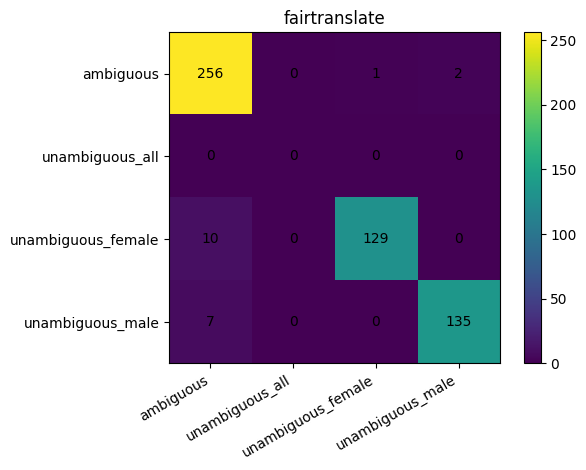

fairtranslate
                    precision    recall  f1-score   support

         ambiguous       0.94      0.99      0.96       259
unambiguous_female       0.99      0.93      0.96       139
  unambiguous_male       0.99      0.95      0.97       142

          accuracy                           0.96       540
         macro avg       0.97      0.96      0.96       540
      weighted avg       0.96      0.96      0.96       540



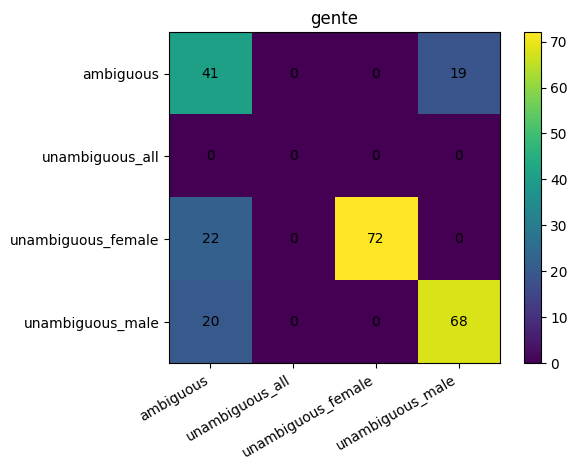

gente
                    precision    recall  f1-score   support

         ambiguous       0.49      0.68      0.57        60
unambiguous_female       1.00      0.77      0.87        94
  unambiguous_male       0.78      0.77      0.78        88

          accuracy                           0.75       242
         macro avg       0.76      0.74      0.74       242
      weighted avg       0.80      0.75      0.76       242



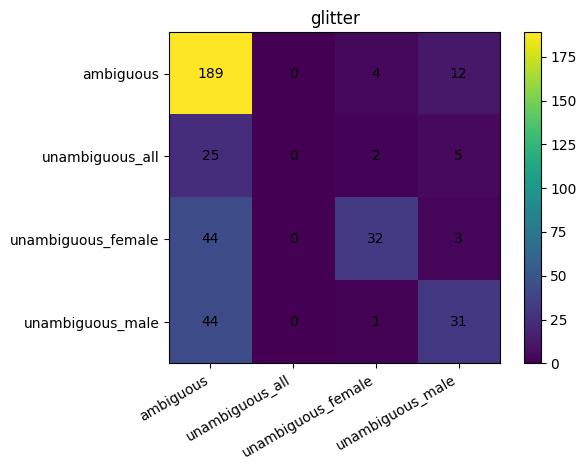

glitter
                    precision    recall  f1-score   support

         ambiguous       0.63      0.92      0.75       205
   unambiguous_all       0.00      0.00      0.00        32
unambiguous_female       0.82      0.41      0.54        79
  unambiguous_male       0.61      0.41      0.49        76

          accuracy                           0.64       392
         macro avg       0.51      0.43      0.44       392
      weighted avg       0.61      0.64      0.59       392



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

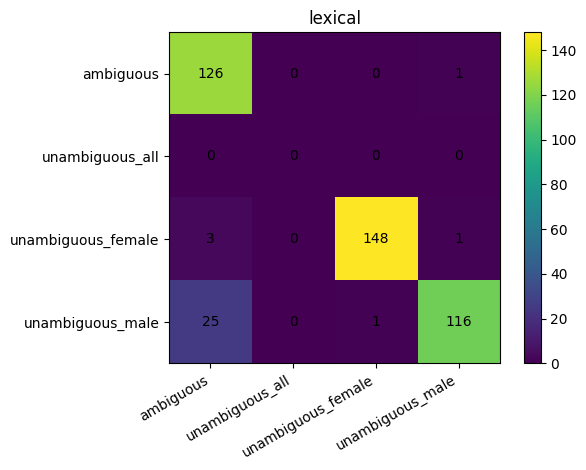

lexical
                    precision    recall  f1-score   support

         ambiguous       0.82      0.99      0.90       127
unambiguous_female       0.99      0.97      0.98       152
  unambiguous_male       0.98      0.82      0.89       142

          accuracy                           0.93       421
         macro avg       0.93      0.93      0.92       421
      weighted avg       0.94      0.93      0.93       421



In [25]:
def evaluate_test(filepath, coref_model, clf, vectorizer, out_path):
    X_dicts, y_true, meta = load_full_dataset(filepath, coref_model)
    X = vectorizer.transform(X_dicts)
    y_pred = clf.predict(X)

    feature_keys = list(X_dicts[0].keys())
    with open(out_path, 'w') as f:
        header = ['seed', 'sentence', 'stereotype', 'dataset_type', 'label', 'predicted'] + feature_keys
        f.write('\t'.join(header) + '\n')
        for m, feature_dict, pred in zip(meta, X_dicts, y_pred):
            row = [m['seed'], m['sentence'], m['stereotype'], m['dataset_type'], m['label'], pred]
            for k in feature_keys:
                row.append(str(feature_dict.get(k, '')))
            f.write('\t'.join(row) + '\n')


    print('overall')
    print(classification_report(y_true, y_pred))


    labels = sorted(set(y_true))
    dataset_types = sorted(set(m['dataset_type'] for m in meta))
    for dt in dataset_types:
        y_true_dt = []
        y_pred_dt = []
        for i, m in enumerate(meta):
            if m['dataset_type'] == dt:
                y_true_dt.append(y_true[i])
                y_pred_dt.append(y_pred[i])

        cm = confusion_matrix(y_true_dt, y_pred_dt, labels=labels)
        plt.figure()
        plt.imshow(cm)
        plt.title(dt)
        plt.xticks(range(len(labels)), labels, rotation=30, ha='right')
        plt.yticks(range(len(labels)), labels)
        plt.colorbar()
        for i in range(len(labels)):
            for j in range(len(labels)):
                plt.text(j, i, cm[i, j], ha='center', va='center')
        plt.tight_layout()
        plt.show()

        print(dt)
        print(classification_report(y_true_dt, y_pred_dt))

In [ ]:
evaluate_test('../../data/full_test.tsv', coref_model, clf, vectorizer, '../../data/features_test.tsv')

In [26]:
import pickle

with open('../results/logreg_model.pkl', 'wb') as f:
    pickle.dump({'clf': clf, 'vectorizer': vectorizer}, f)